In [1]:
import torch
import numpy as np
import torchvision
import matplotlib.pyplot as plt
import torch.nn as nn

In [58]:
size = 6

In [41]:
## Creating tensors
x=torch.empty(size,dtype=torch.float16)
y=torch.randn(size)
z=torch.zeros(size)
p=torch.ones(size)

## From list
list1 = [1,2,3]
m = torch.tensor(list1)


## Operations
#y.add_(x) # replaces y elements with x (inplace=True)


In [45]:

no_col = 2
## Reshaping 
z = x.view(-1,no_col) #(reshape in numpy)
z

tensor([[0., 0.],
        [0., 0.],
        [0., 0.]], dtype=torch.float16)

In [46]:

numpy_array = np.array(list1)
## Converting numpy array to pytorch-tensor
a = torch.from_numpy(numpy_array)


In [52]:

## Converting pytorch-tensor to numpy array
x.numpy()


array([0., 0., 0., 0., 0., 0.], dtype=float16)

In [59]:
## Computing with GPU
if(torch.cuda.is_available()):
    device = torch.device('cuda')

    x = torch.ones(5,device=device)
    y = torch.ones(5)
    y = y.to(device)
    z = x+y
    z = z.to('cpu')
    print(z)
else:
    print('Unable to calculate')


tensor([2., 2., 2., 2., 2.])



### Calculating gradients
### Autograd (Gradient Calculations)
#### Requires_grad should be true for gradient calculations (dy/dx -> diff. w.r.to x)

In [64]:


x = torch.randn(3,requires_grad=True)

print(x)

y = x+2
z = y*y*2
z = z.mean()
#Backward propagation
z.backward()
print(x.grad)



tensor([1.0480, 0.1915, 1.5456], requires_grad=True)
tensor([4.0640, 2.9220, 4.7274])


In [61]:

### Preventing from grad calculations
#x.requires_grad(False)
#x.detach()
#with torch.no_grad():
x.requires_grad_(False)


tensor([ 1.1128,  0.0139, -1.4813])

In [62]:
x.detach()

tensor([ 1.1128,  0.0139, -1.4813])

### Backpropagation

In [66]:
## x ---> a(x) --->y ---->b(y) ----> z

#Chain Rule:
#    del(z)/del(x) = del(z)/dely * del(y)/del(x)

#Computaional Graph

# x,y --> * (f=x.y) --> z--> Loss
# del(z)/del(x) = del(xy)/del(x) = y
# del(z)/del(y) = del(xy)/del(x) = x

# del(loss)/del(x) = del(loss)/del(z) * del(z)/del(x)
#We calculate the gradient for only weights(theta) not feartures(x)

In [70]:
x = torch.tensor(1.0)
y = torch.tensor(2.0)
weight = torch.tensor(1.0,requires_grad=True)

#Forward pass and compute loss
y_hat = weight*x
loss = (y_hat-y)**2

print(loss)

#Backward pass
loss.backward()

weight.grad #del(loss)/del(weight)

#Updating weights
#Loop continues

tensor(1., grad_fn=<PowBackward0>)


tensor(-2.)

### Gradient Descent

In [93]:
x = torch.tensor([1,2,3,4,5],dtype=torch.float32)
Y = torch.tensor([2,4,6,8,10],dtype=torch.float32)
weights = torch.tensor(0.0,dtype=torch.float32,requires_grad =True)
learning_rate = 0.01
n_iters = 100

#Loss func
loss = torch.nn.MSELoss()

#Stochastic gradient descent
optimizer = torch.optim.SGD([weights],lr=learning_rate)

In [97]:
print('Training...')
for epoch in range(n_iters):
    #Prediction(forward pass)
    y_pred = forward(x)
    
    #loss
    l = loss(Y,y_pred)
    
    #Backward propagation
    l.backward()
    
    #Updating weights
    optimizer.step()
    
    #Making grad zero
    weights.grad.zero_()
    
    if epoch % 10 == 0:
        print(f'epoch {epoch+1} : weights = {weights:.3f}, loss = {l:.8f}')
print(f'Prediction after training : f(5) = {forward(5):.3f}')
    

Training...
epoch 1 : weights = 2.000, loss = 0.00000000
epoch 11 : weights = 2.000, loss = 0.00000000
epoch 21 : weights = 2.000, loss = 0.00000000
epoch 31 : weights = 2.000, loss = 0.00000000
epoch 41 : weights = 2.000, loss = 0.00000000
epoch 51 : weights = 2.000, loss = 0.00000000
epoch 61 : weights = 2.000, loss = 0.00000000
epoch 71 : weights = 2.000, loss = 0.00000000
epoch 81 : weights = 2.000, loss = 0.00000000
epoch 91 : weights = 2.000, loss = 0.00000000
Prediction after training : f(5) = 10.000


In [108]:
### Using functions from torch
X = x.view(-1,1)
Y_new = Y.view(-1,1)
n_samples,n_features = X.shape
input_size = n_features
output_size = n_features
model = torch.nn.Linear(input_size,output_size)

#Loss func
loss = torch.nn.MSELoss()

#Stochastic gradient descent
optimizer = torch.optim.SGD(model.parameters(),lr=learning_rate)

In [117]:
print('Training...')
for epoch in range(n_iters):
    #Prediction(forward pass)
    y_pred = model(X)
    
    #loss
    l = loss(Y_new,y_pred)
    
    #Backward propagation
    l.backward()
    
    #Updating weights
    optimizer.step()
    
    #Making grad zero
    weights.grad.zero_()
    
    if epoch % 10 == 0:
        print(f'epoch {epoch+1} : weights = {weights:.3f}, loss = {l:.8f}')
print(f'Prediction after training : f(5) = {forward(5):.3f}')


Training...
epoch 1 : weights = 2.000, loss = 11.39548683
epoch 11 : weights = 2.000, loss = 3.49139476
epoch 21 : weights = 2.000, loss = 6.37690830
epoch 31 : weights = 2.000, loss = 7.22175312
epoch 41 : weights = 2.000, loss = 2.95383215
epoch 51 : weights = 2.000, loss = 11.84871578
epoch 61 : weights = 2.000, loss = 1.07181168
epoch 71 : weights = 2.000, loss = 11.17183876
epoch 81 : weights = 2.000, loss = 1.37611699
epoch 91 : weights = 2.000, loss = 8.56298256
Prediction after training : f(5) = 10.000


In [119]:
predicted   = model(X).detach().numpy() 
predicted

array([[ 4.715968 ],
       [ 6.6348076],
       [ 8.553647 ],
       [10.4724865],
       [12.391326 ]], dtype=float32)

### Making custom models

In [115]:

class LinearRegression(torch.nn.Module):
    def __init__(self,input_size,output_size):
        super(LinearRegression,self).__init__()
        #Define layers
        self.model = nn.Linear(input_size,output_size)
        
    def forward(self,x):
        return self.model(x)

### Loading and saving model

In [120]:
#Saving Model
#torch.save(model.load_state_dict(arg),PATH)

#Loading Model
#model = Model)(*args,**kwargs)
#model.load_state_dict(torch.load(PATH))
#model.eval()

### Neural Network

In [38]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_size = 784
hidden_size = 100
num_classes = 10
num_epocs = 2
batch_size = 100
learning_rate = 0.001



#### Loading MNIST data-set


In [39]:

train_dataset = torchvision.datasets.MNIST(root='./data',train=True,transform=torchvision.transforms.ToTensor(),download=True)
test_dataset = torchvision.datasets.MNIST(root='./data',train=False,transform=torchvision.transforms.ToTensor())

#### Creating Data Loader

In [40]:
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,batch_size=batch_size,shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=train_dataset,batch_size=batch_size,shuffle=False)

In [41]:
examples = iter(train_loader)
samples,labels = examples.next()

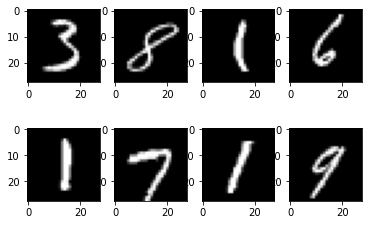

In [42]:
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(samples[i][0],cmap='gray')
plt.show()

### Creating Neural Network

In [48]:
class NeuralNetwork(nn.Module):
    def __init__(self,input_size,output_size,hidden_size):
        super(NeuralNetwork,self).__init__()
        self.l1 = nn.Linear(input_size,hidden_size)
        self.l2 = nn.Linear(hidden_size,output_size)
        self.relu = nn.ReLU()
    def forward(self,x):
        out = self.l1(x)
        out = self.relu(out)
        out = self.l2(out)
        return out
        

In [49]:
model = NeuralNetwork(input_size,num_classes,hidden_size)

In [50]:
#Loss and Optimizer
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)

In [53]:
num_total_steps = len(train_loader)
#Training loop
for epoch in range(num_epocs):
    for i,(images,labels) in enumerate(train_loader):
        #Batch size 100,1,28,28
        
        images = images.reshape(-1,28*28).to(device)
        labels = labels.to(device)
        images = images.to('cpu')
        labels = labels.to('cpu')
        
        #Forward pass
        outputs = model(images)
        ls = loss(outputs,labels)
        
        #Backward pass
        #Empty the values in grad
        optimizer.zero_grad()
        
        ls.backward()
        
        #Updating weights
        optimizer.step()
        
        if((i+1) % 100 == 0):
            print(f'epoch {epoch+1} / {num_epocs} ,step {i+1}/{num_total_steps}, loss = {ls.item():.4f}')
            

        

epoch 1 / 2 ,step 100/600, loss = 0.1110
epoch 1 / 2 ,step 200/600, loss = 0.1018
epoch 1 / 2 ,step 300/600, loss = 0.1930
epoch 1 / 2 ,step 400/600, loss = 0.3338
epoch 1 / 2 ,step 500/600, loss = 0.0719
epoch 1 / 2 ,step 600/600, loss = 0.0985
epoch 2 / 2 ,step 100/600, loss = 0.0919
epoch 2 / 2 ,step 200/600, loss = 0.0442
epoch 2 / 2 ,step 300/600, loss = 0.0422
epoch 2 / 2 ,step 400/600, loss = 0.0297
epoch 2 / 2 ,step 500/600, loss = 0.1582
epoch 2 / 2 ,step 600/600, loss = 0.1644


In [ ]:
#Testing 
with torch.no_grad():
    n_correct = 0
    n_samples = 0
    
    for images , labels in test_loader:
        images = images.reshape(-1,28*28).to(device)
        labels = labels.to(device)
        images = images.to('cpu')
        labels = labels.to('cpu')
        
        outputs = model(images)
        
        #val,index
        _,predictions = torch.max(outputs,1)
        n_samples += labels.size(0)
        n_correct += (predictions == labels).sum().item()
        
        
#Accuracy
acc= (n_correct/n_samples)*100.0
print('Accuracy :',acc)      

In [75]:
def predict_random():
    test_data = iter(test_loader)
    test_samp,test_label = test_data.next()
    idx = np.random.randint(low=0,high=len(test_samp))
    with torch.no_grad():

        image = test_samp[idx][0].reshape(-1,28*28)
        label = test_label[idx]

        output = model(image)

        #val,index
        _,predict = torch.max(output,1)
        print(f'{label} : Predcited as {predict}')
        plt.imshow(image.reshape(-1,28),cmap='gray')
        plt.show()

1 : Predcited as tensor([1])


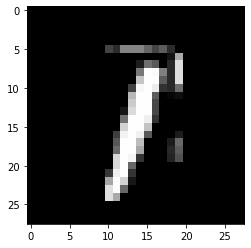

In [84]:
predict_random()

In [2]:
#### Dataloder and transforms

In [12]:
from torch.utils.data import DataLoader,Dataset
import pandas as pd
import torch
import torchvision

In [14]:
class CustomDataset(Dataset):
    def __init__(self,filename,transform=None,max_samples=-1,plot=False):
        self.transform = transform
        self.max_samples = max_samples
        self.data = pd.read_csv(filename,index_col=0)
        self.data['env'] = self.data['env'].apply(lambda x : os.path.join(os.getcwd(),x))
        # Object to encode the labels. 
        label_encoder = preprocessing.LabelEncoder()

        # Encode labels in column 'labels'. 
        self.data['labels']= label_encoder.fit_transform(self.data['labels'])
        
        if not(self.max_samples == -1):
            self.remove_extras()
        if plot:
            self.plot_data()
        
        # Separating the data into inputs and outputs
        self.inputs = self.data['env'].to_numpy().reshape(-1,1)
    
        # Performing one hot encoding. 
        self.outputs = pd.get_dummies(self.data, columns = ['labels']).iloc[:,2:].to_numpy()

        
    def plot_data(self,data,data_label=None):
        ax = sns.countplot(x="labels", hue='labels',data=self.data)
        ax.set_xlabel("Range of speed (in km/hr)")
        ax.set_ylabel("No. of samples")
        ax.set_title('Data Summary')
        ax.legend(loc='upper right')
        if self.max_samples > 0:
            ax.plot([0,self.data['labels'].max()],[self.max_samples,self.max_samples],label='Max samples')
        ax.legend()

        def __getitem__(self,index):
            if self.transform:
                return self.transform(self.inputs[index]),self.outputs[index]
            return self.inputs[index],self.outputs[index]
        def __len__(self):
            return self.data.shape[0]
    
    def remove_extras(self,data):
        #Getting bins
            _,bins = np.histogram(self.data['labels'],4)

            #Getting the interval
            dn = self.data['labels'].groupby(pd.cut(self.data['labels'], bins)).count()

            #Max no. of samples
            max_num_vals = dn.loc[dn.idxmax()]

            #Range of max samples
            interval = dn.idxmax()

            removable_items = []

            #Removing the items if the size is greater than the max size
            if max_num_vals > MAX_SAMPLE_SIZE:
                    #Getting thee index of the items
                    items = self.data.index[(interval.left < self.data['labels']) & (self.data['labels'] <= interval.right)].tolist()

                    #Shuffling the removable data indices 
                    random.shuffle(items)

                    #Selecting the removable element indices
                    removable_items = items[MAX_SAMPLE_SIZE:]

                    #Dropping the rows
                    self.data.drop(removable_items,inplace=True)

                    #Resettingthe indices
                    self.data.reset_index(inplace = True, drop = True)
        

In [16]:
class ConvertColor:
    def __call__(self,sample):
        sample = cv2.cvtColor(sample,cv2.COLOR_RGB2YUV)
        return sample
trandforms = torchvision.transforms.Compose([ConvertColor(),
                                             torchvision.transforms.ToTensor(),
                                             torchvision.transforms.GaussianBlur(5),
                                             torchvision.transforms.Resize((200,66)),
                                             torchvision.transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])


In [ ]:
dataset = CustomDataset('./data/data.csv')
data_loader = DataLoader(dataset=dataset,batch_size=20,shuffle=True,num_workers=2)